In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# Compare

只读取 `notebooks/record/` 中已经存在的 canonical rollout 记录，不再触发训练、shared-data 构建或 MPC 重算。

In [2]:

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from configs.experiment_config import COMPARE_SCHEME_ORDER, RECORD_SCHEME_CATEGORIES
from configs.profiles import project_root
from scripts.mainline_compare import build_compare_economic_table, build_compare_safety_table, compare_rollout_metrics
from scripts.plots.grid_notebook_plotting import (
    plot_battery_power_and_soc_comparison,
    plot_net_load_comparison,
    plot_power_balance_comparison,
    plot_price_prediction_comparison,
    plot_voltage_profile_comparison,
)
from scripts.utils.grid_notebook_workflow import assert_rollout_timestamp_alignment, load_rollout_record


,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Global MISOCP,continuous,881.787065,1421.710765,539.923700,-539.923700,1601.493344,-1061.569655,0.005283,0.007101,...,0.013556,0.057718,0.012438,0.052119,0,97.855133,25.723625,293.783783,45.641957,-538.368422
1,Local MPC + Perfect Forecast,continuous,592.825361,951.069341,358.243980,-358.243980,NaN,NaN,0.001958,0.117591,...,0.019889,0.071552,0.009759,0.054899,114,170.051804,34.118818,347.481476,39.954731,NaN
2,Local MPC + LSTM Forecast,continuous,381.124897,532.511705,151.386808,-151.386808,NaN,NaN,0.003171,0.279804,...,0.022627,0.079855,0.010278,0.057440,81,178.865463,41.958426,390.804901,32.971992,NaN
3,ADMM MPC + LSTM Forecast,continuous,360.276817,589.380954,229.104137,-229.104137,NaN,NaN,0.005299,0.004058,...,0.015351,0.054800,0.010650,0.054353,39,101.157211,33.628344,281.227081,28.597237,NaN
4,MADRL + No Safety + LSTM Forecast,continuous,790.519210,1073.495073,282.975864,-282.975864,NaN,NaN,0.005176,0.000000,...,0.011640,0.058885,0.012883,0.049296,30,160.051239,30.162013,207.435623,41.226791,NaN
5,MADRL + Safety Penalty + LSTM Forecast,continuous,792.950118,822.989747,30.039629,-30.039629,NaN,NaN,0.003650,0.000000,...,0.010702,0.040036,0.012562,0.039562,13,119.154274,29.387093,156.147041,34.854585,NaN
6,MADRL + Safety Projection + LSTM Forecast,continuous,748.773795,1011.008619,262.234824,-262.234824,NaN,NaN,0.004067,0.000071,...,0.010783,0.055121,0.013046,0.054060,5,107.487099,27.251569,152.917084,40.002316,NaN


,controller,storage_discharge_revenue_total_eur,storage_charge_cost_total_eur,storage_profit_total_eur
0,Global MISOCP,1421.710765,881.787065,539.923700
1,Local MPC + Perfect Forecast,951.069341,592.825361,358.243980
2,MADRL + No Safety + LSTM Forecast,1073.495073,790.519210,282.975864
3,MADRL + Safety Projection + LSTM Forecast,1011.008619,748.773795,262.234824
4,ADMM MPC + LSTM Forecast,589.380954,360.276817,229.104137
5,Local MPC + LSTM Forecast,532.511705,381.124897,151.386808
6,MADRL + Safety Penalty + LSTM Forecast,822.989747,792.950118,30.039629


,controller,voltage_violation_steps,voltage_violation_bus_points,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw
0,Global MISOCP,21,38,0.013556,0.057718,0.012438,0.052119,0,97.855133,25.723625,293.783783
1,Local MPC + Perfect Forecast,20,38,0.019889,0.071552,0.009759,0.054899,114,170.051804,34.118818,347.481476
2,Local MPC + LSTM Forecast,32,62,0.022627,0.079855,0.010278,0.057440,81,178.865463,41.958426,390.804901
3,ADMM MPC + LSTM Forecast,16,30,0.015351,0.054800,0.010650,0.054353,39,101.157211,33.628344,281.227081
4,MADRL + No Safety + LSTM Forecast,8,15,0.011640,0.058885,0.012883,0.049296,30,160.051239,30.162013,207.435623
5,MADRL + Safety Penalty + LSTM Forecast,0,0,0.010702,0.040036,0.012562,0.039562,13,119.154274,29.387093,156.147041
6,MADRL + Safety Projection + LSTM Forecast,3,5,0.010783,0.055121,0.013046,0.054060,5,107.487099,27.251569,152.917084


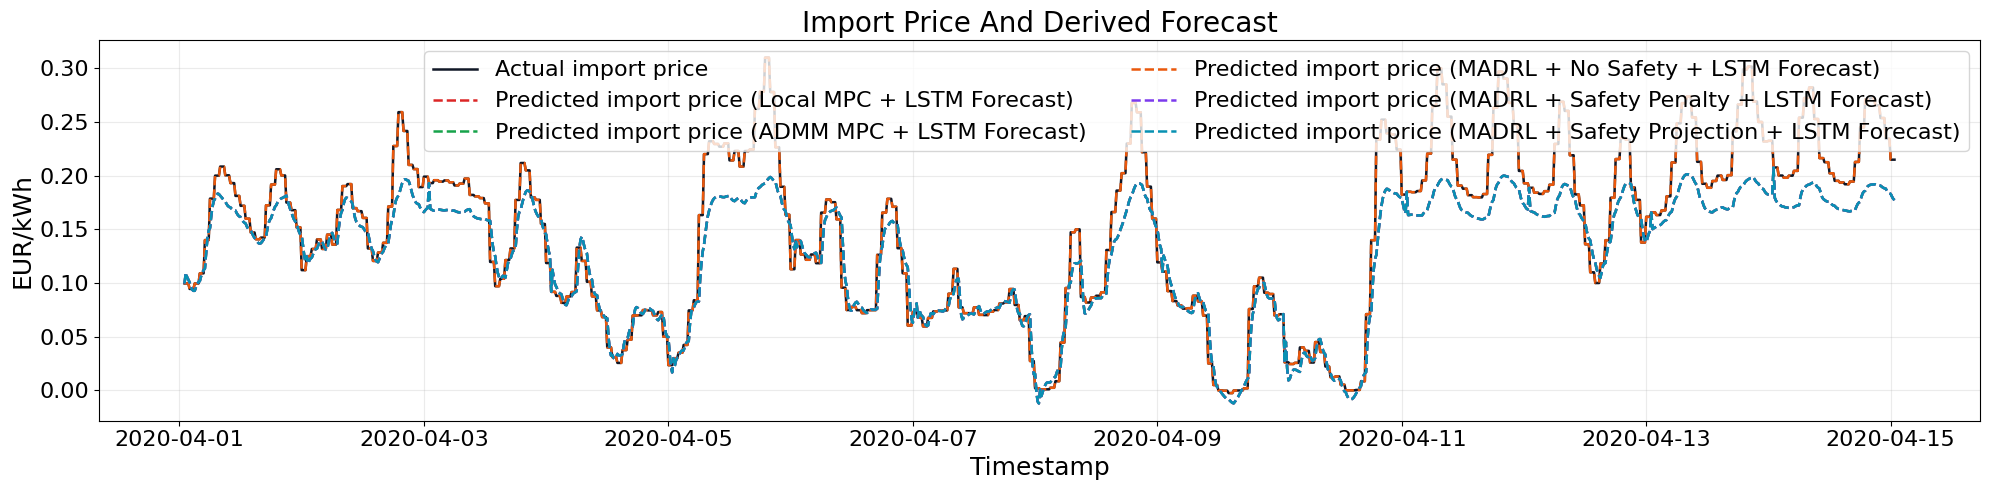

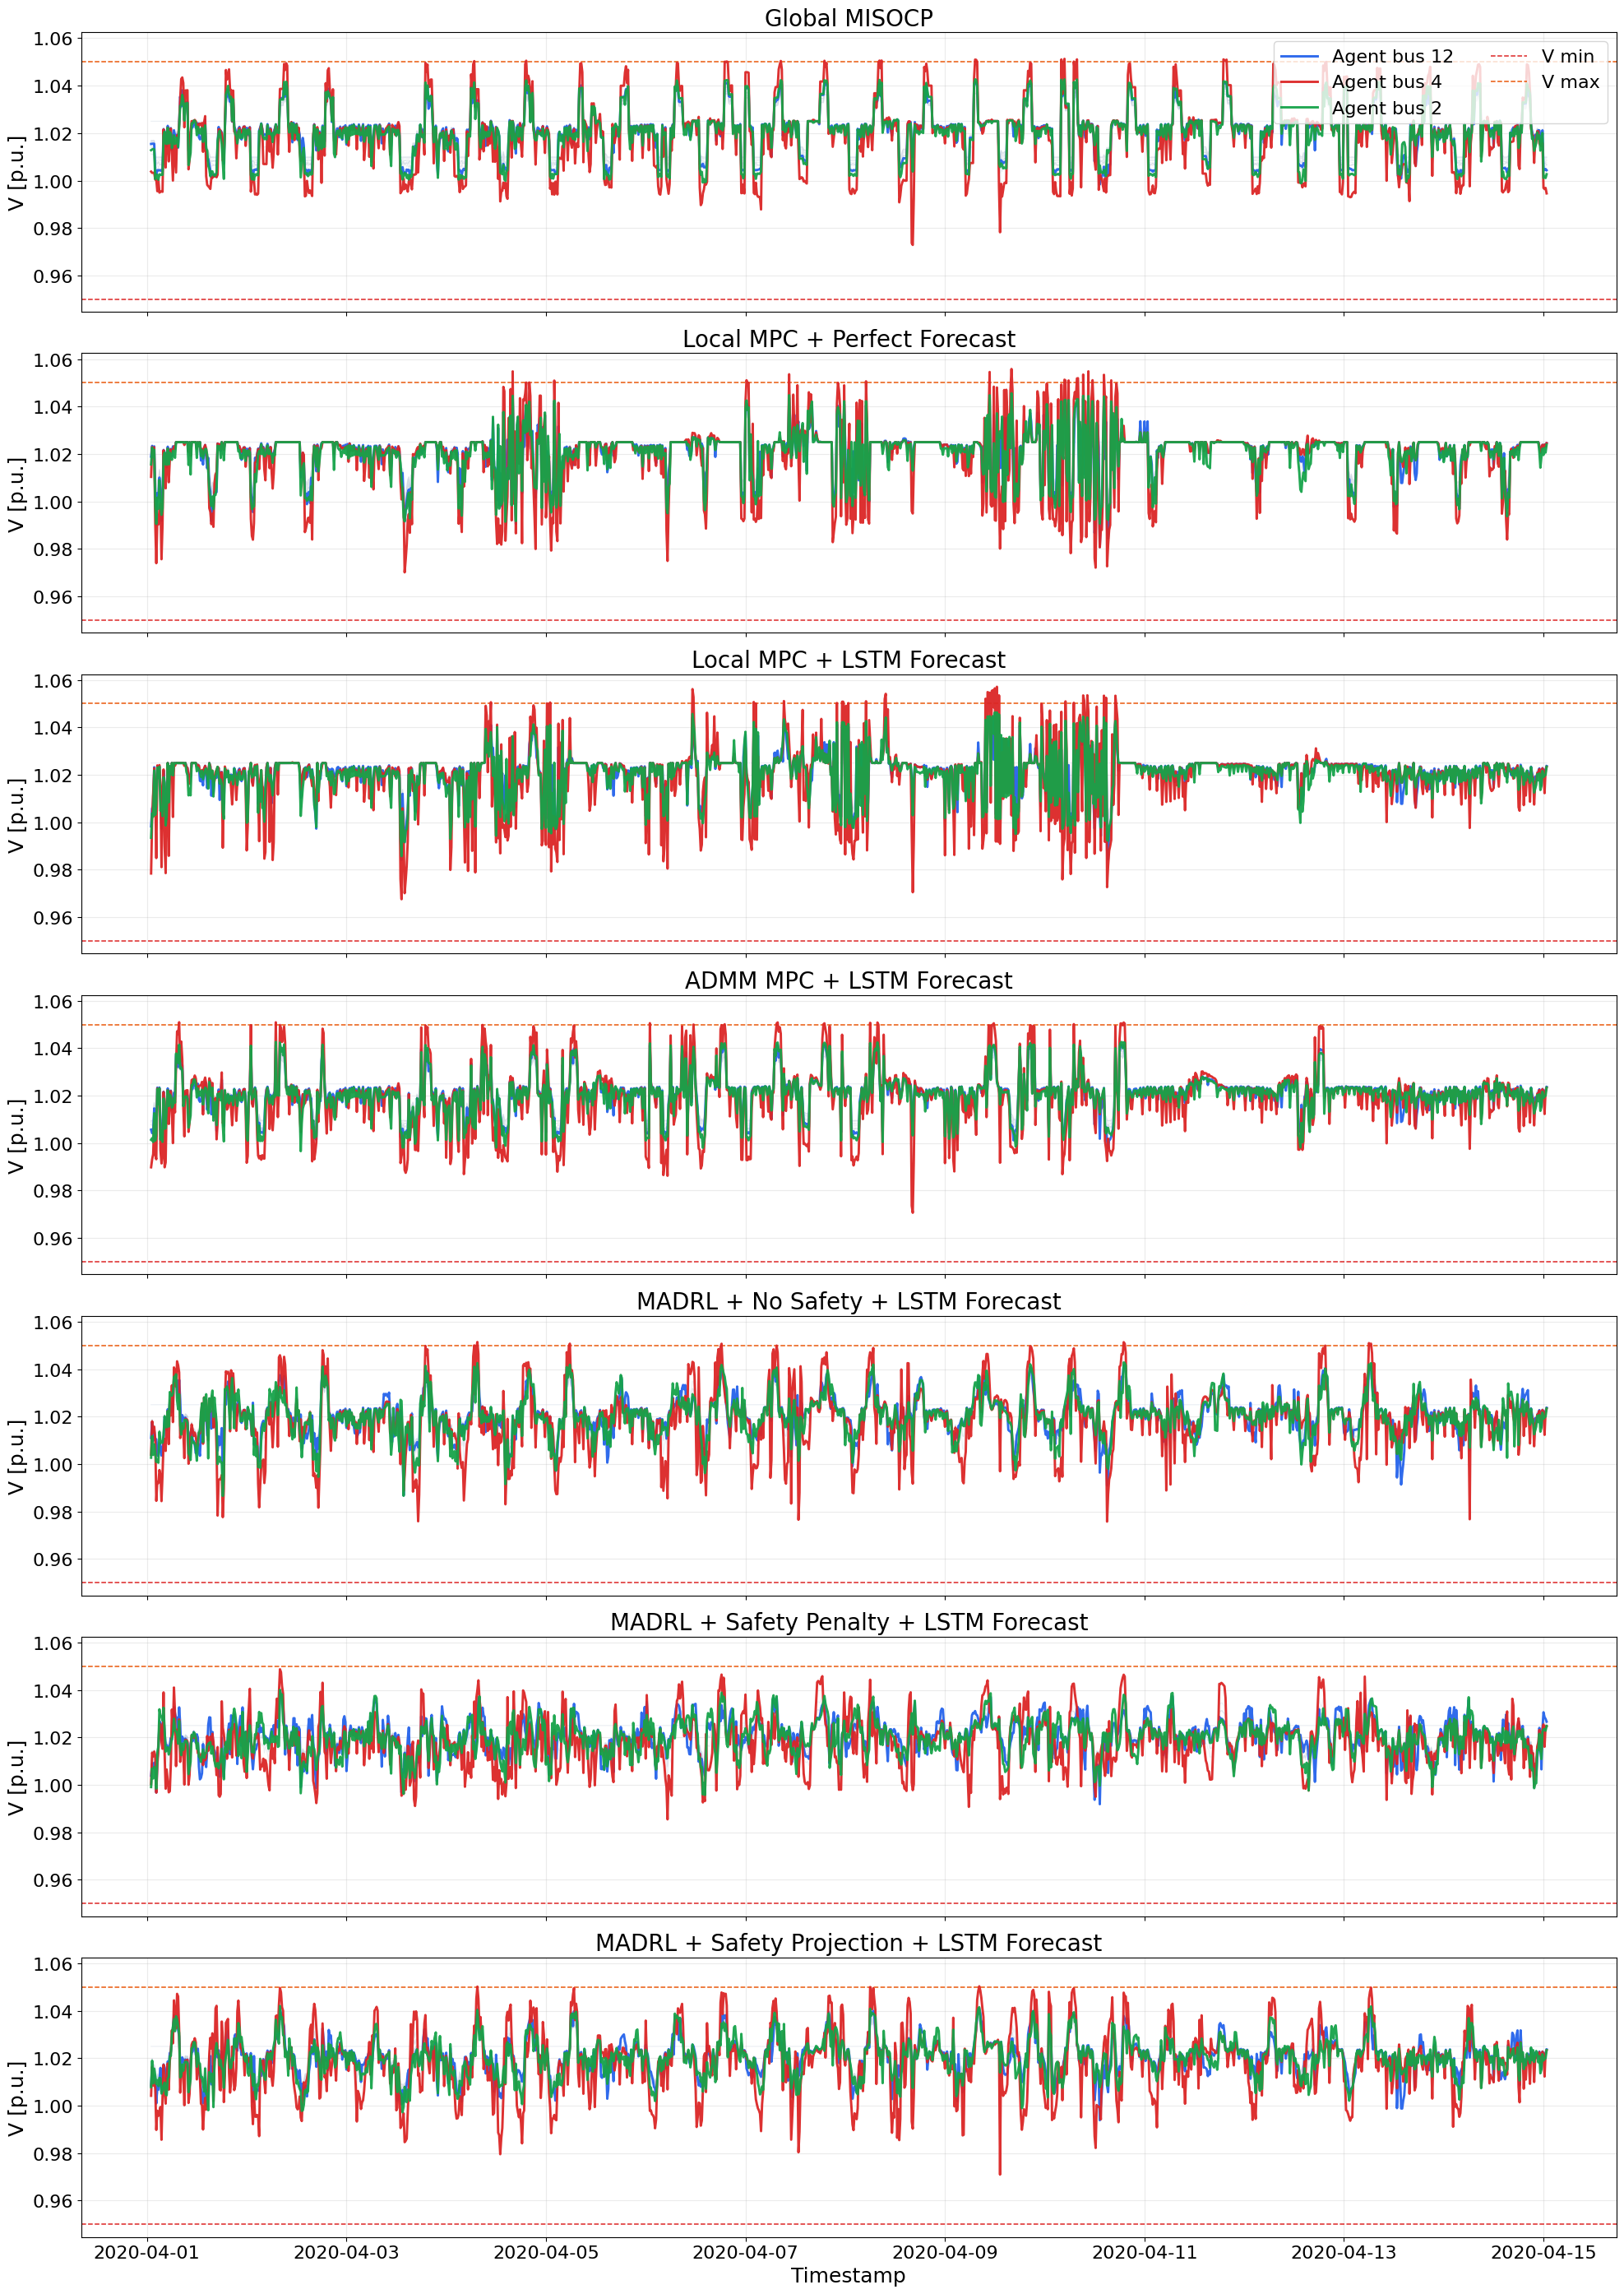

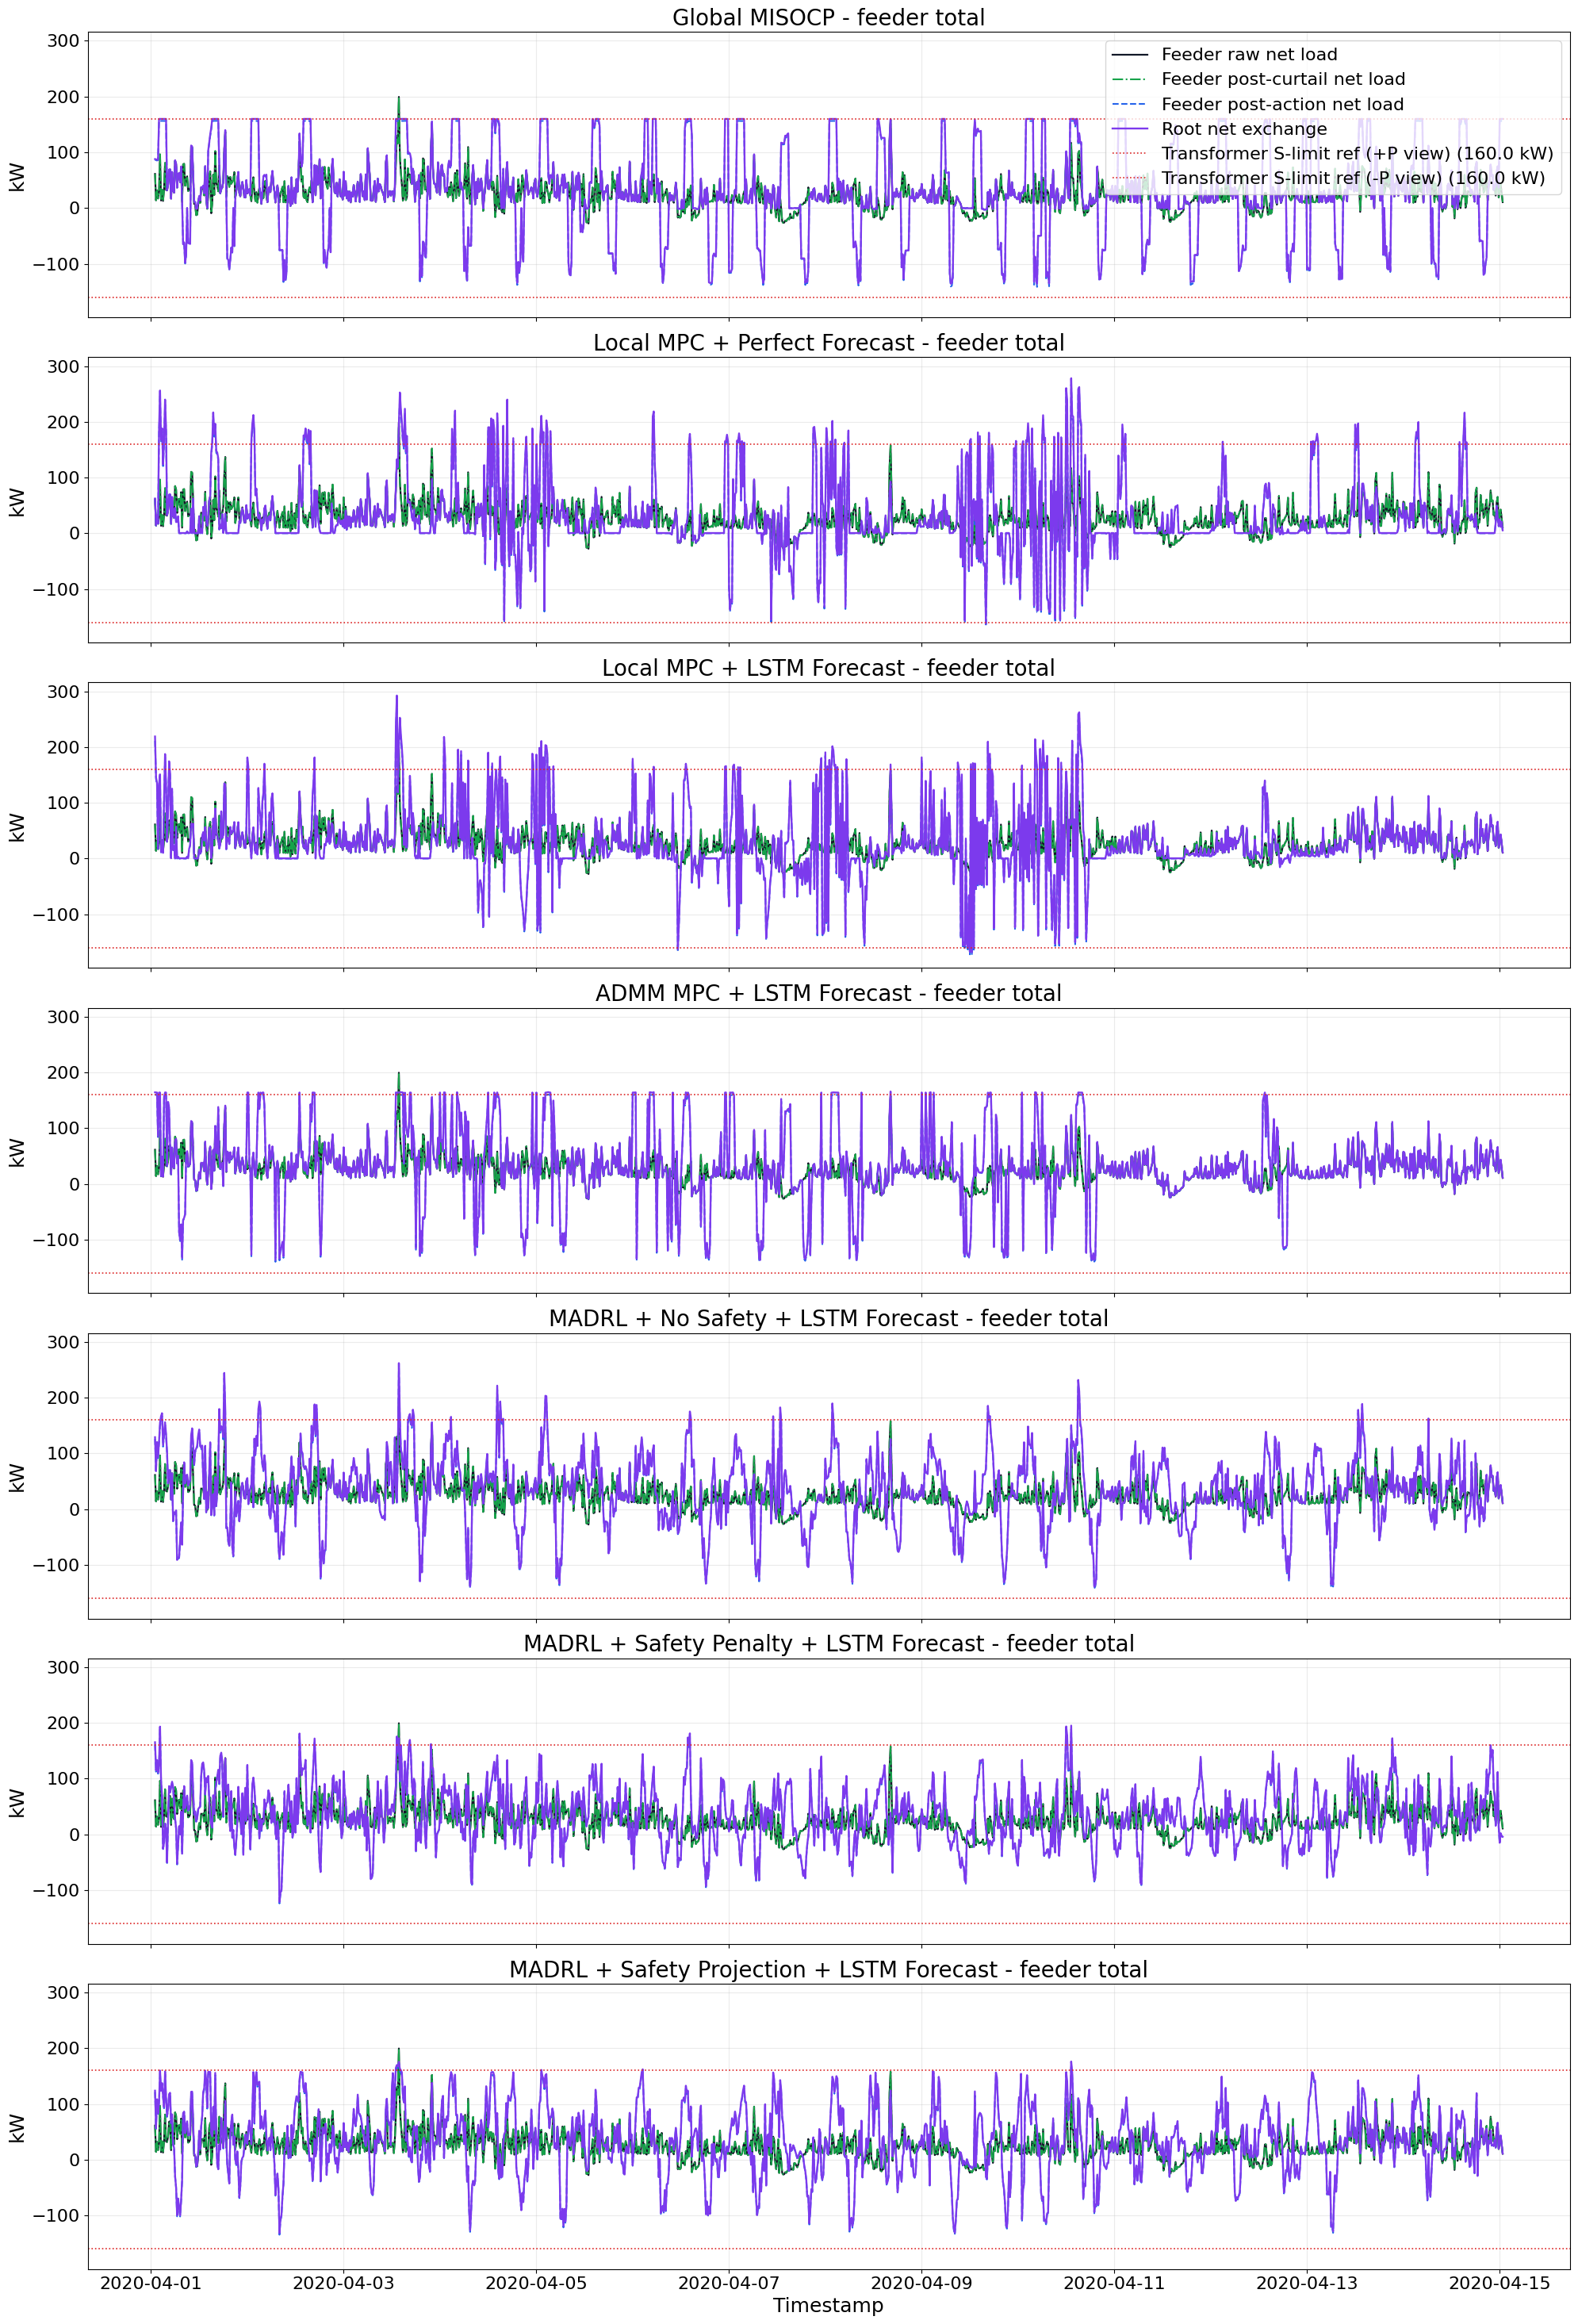

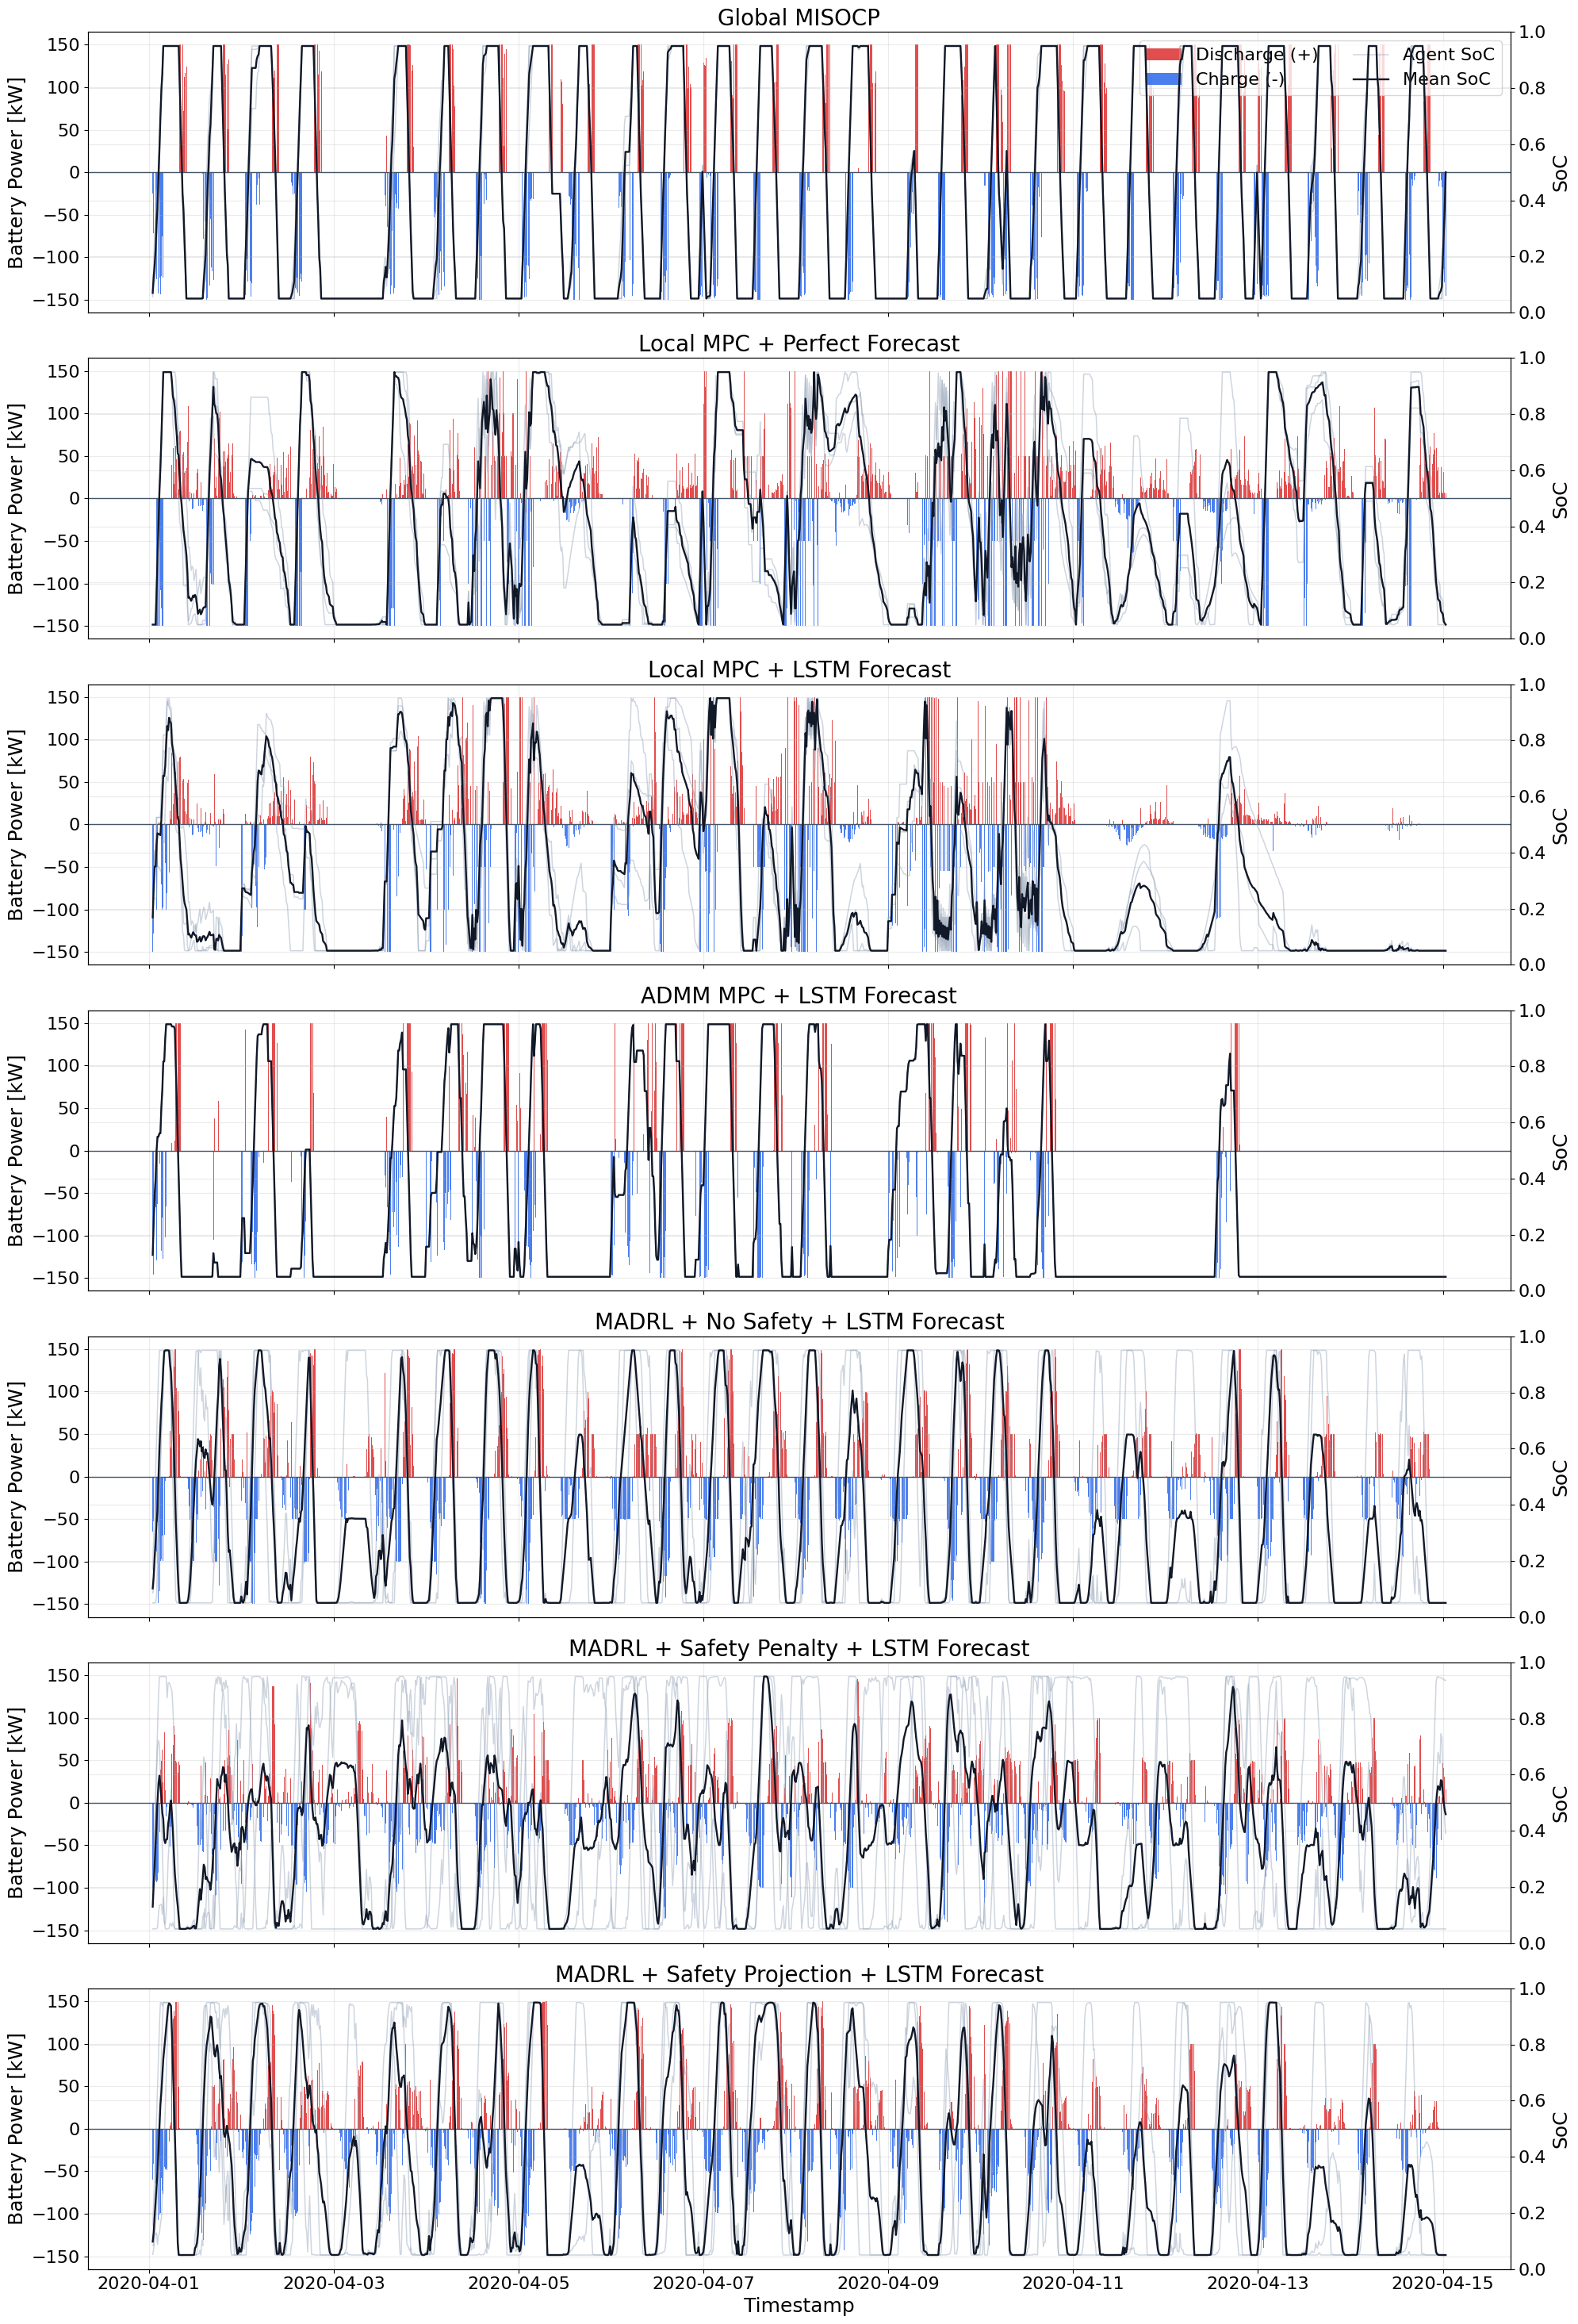

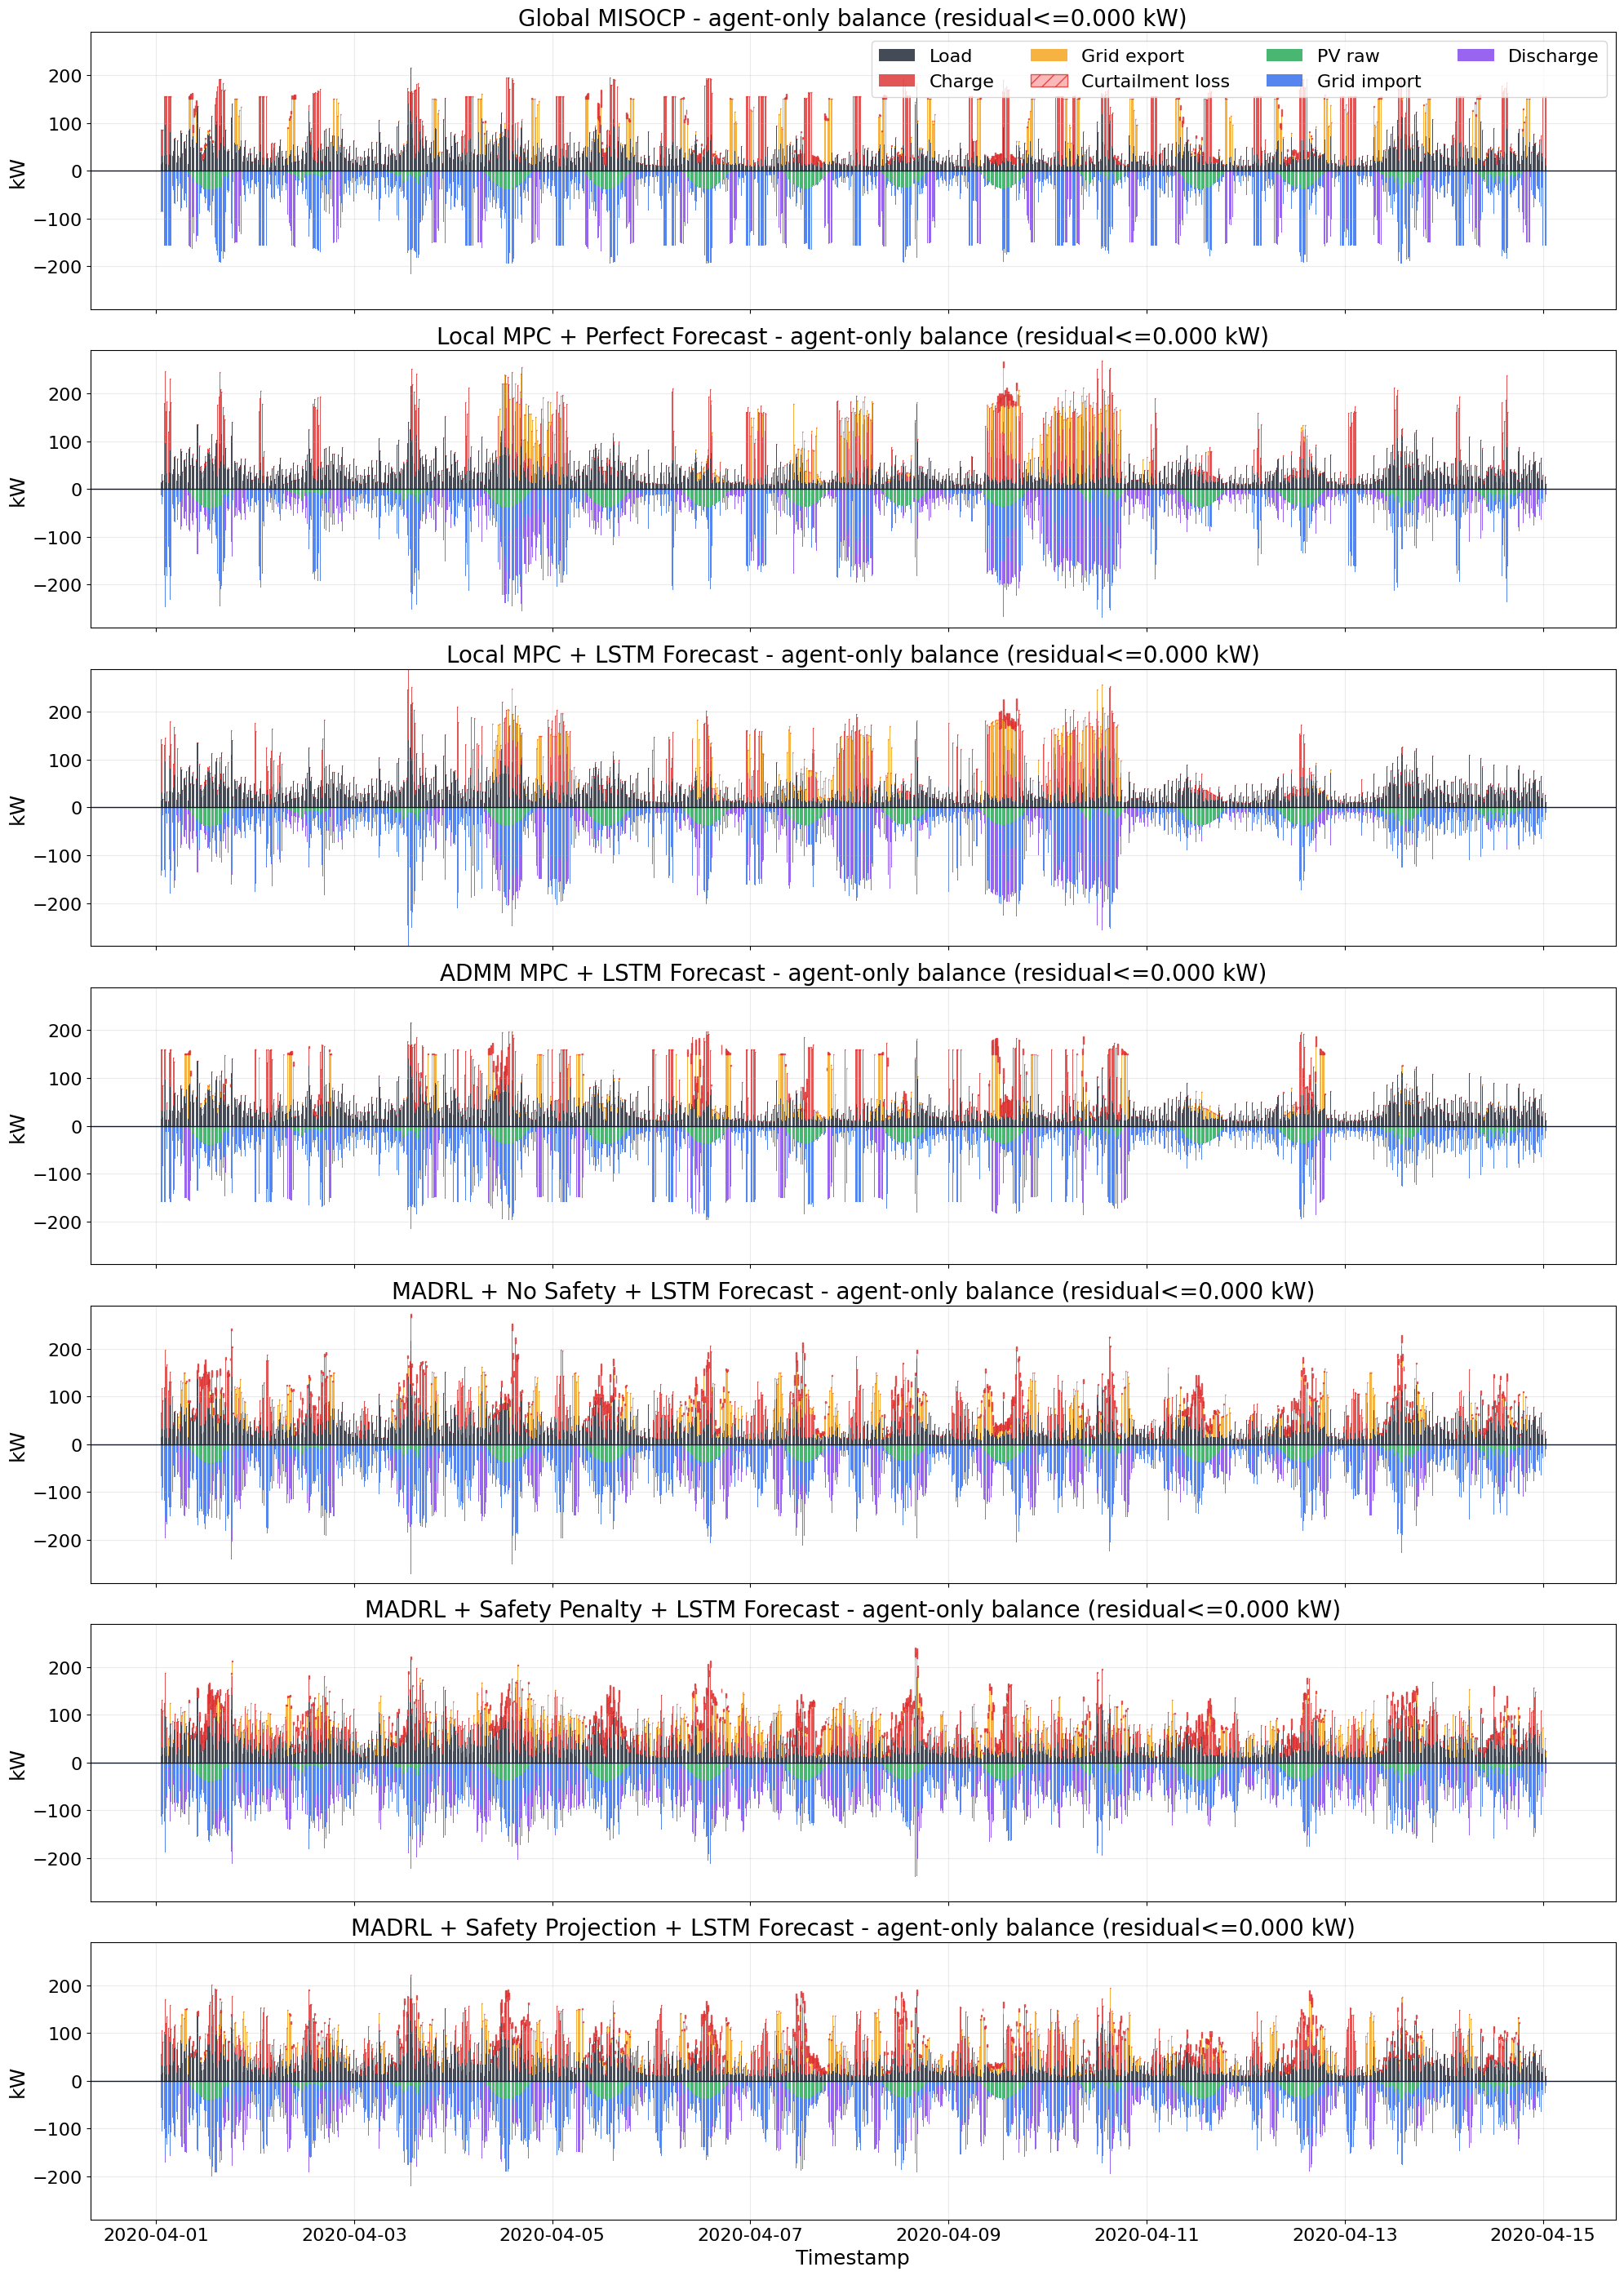

In [3]:

root = project_root()
rollouts = [load_rollout_record(category=RECORD_SCHEME_CATEGORIES[scheme_name], scheme_name=scheme_name, root=root) for scheme_name in COMPARE_SCHEME_ORDER]
assert_rollout_timestamp_alignment(*rollouts)
metrics_df = compare_rollout_metrics(*rollouts)
economic_table = build_compare_economic_table(metrics_df)
safety_table = build_compare_safety_table(metrics_df)

display(metrics_df)
display(economic_table)
display(safety_table)

plot_price_prediction_comparison(*rollouts)
plt.show()
plot_voltage_profile_comparison(*rollouts)
plt.show()
plot_net_load_comparison(*rollouts)
plt.show()
plot_battery_power_and_soc_comparison(*rollouts)
plt.show()
plot_power_balance_comparison(*rollouts)
plt.show()
